# **Finetuning for Classification**

This chapter covers:

- **Introducing different LLM finetuning approaches**
- **Preparing a dataset for text classification**
- **Modifying a pretrained LLM for finetuning**
- **Finetuning an LLM to identify spam messages**
- **Evaluating the accuracy of a finetuned LLM classifier**
- **Using a finetuned LLM to classify new data**

![Alt text](../../assests/figure61.png)

Figure above: A mental model of the three main stages of coding an LLM, pretraining the LLM on a general text dataset and finetuning it. This section focuses on finetuning a pretrained LLM as a classifier.

### **1. Different categories of finetuning**

- The most common ways to finetune language models are instruction-finetuning and classification finetuning

- Instruction-finetuning involves training a language model on a set of tasks using specific instructions to improve its ability to understand and execute tasks described in natural language prompts.


![Alt text](../../assests/figure62.png)

The figure above shows two-different instruction-finetuning scenarios. At the top, the model is tasked with determining whether a given text is spam. At the bottom, the model is given an instruction on how to translate an Englidh sentence into German.

- Classification finetuning, the topic of this chapter, is a procedure you may already be familiar with if you have a background in machine learning -- it's similar to training a `convolutional network` to classify handwritten digits, for example.

- In classification finetuning, we have a specific number of class labels (for example, "spam" and "not spam") that the model can output.

- A classification finetuned model can only predict classes it has seen during training (for example, "spam" or "not spam"), whereas an instruction-finetuned model can usually perform many tasks.

- We can think of a classification-finetuned model as a very specialized model; in practice, it is much easier to create a specialized model than a generalist model that performs well on many different tasks


![Alt text](../../assests/figure63.png)


- A model finetuned for spam classification does not require further instruction alongside the input. In contrast to an instruction-finetuned model, it can only respond with "spam" and "not spam."

**CHOOSING THE RIGHT APPROACH**

```
Instruction-finetuning improves a model's ability to understand and generate responses based on specific user instructions. Instruction-finetuning is best suited for models that need to handle a variety of tasks based on complex user instructions, improving flexibility and interaction quality. Classification-finetuning, on the other hand, is ideal for projects requiring precise categorization of data into predefined classes, such as sentiment analysis or spam detection.

While instruction-finetuning is more versatile, it demands larger datasets and greater computational resources to develop models proficient in various tasks. In contrast, classification-finetuning requires less data and compute power, but its use is confined to the specific classes on which the model has been trained.
```

### **2. Preparing the dataset**


- This section prepares the dataset we use for classification finetuning.

- We use a dataset consisting of spam and non-spam text messages to finetune the LLM to classify them

- First, we download and unzip the dataset


![Alt text](../../assests/figure64.png)

* stage 1: Dataset preparation
* stage 2: focuses on model setup
* stage 3: covers the finetuning and evaluation of the model.

In [2]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path) 

File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


- After executing the preceding code, the dataset is saved as a tab-separated text file, `SMSSpamCollection.tsv`, in the `sms_spam_collection` folder. We can load it into a pandas DataFrame as follows:

In [4]:
import pandas as pd
df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


- When we check the class distribution, we see that the data contains `"ham"` (i.e., `"not spam"`) much more frequently than `"spam"`

In [5]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


- For simplicity, and because we prefer a small dataset for educational purposes anyway (it will make it possible to finetune the LLM faster), we subsample (undersample) the dataset so that it contains 747 instances from each class

- Next to undersampling, there are several other ways to deal with class balances, but they are out of the scope of a book on LLMs.

In [9]:
def create_balanced_dataset(df):
    
    # Count the instances of "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # Randomly sample "ham" instances to match the number of "spam" instances
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    
    # Combine ham "subset" with "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


- Next, we change the string class labels `"ham"` and `"spam"` into integer class labels `0` and `1`, respectively:

In [10]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})    

In [11]:
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


- This process is similar to converting text into token IDs.

- We create a `random_split` function to split the dataset into three parts:
  - 70% for training
  - 10% for validation, and
  - 20% for testing.

In [12]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

In [15]:
train_df.shape, validation_df.shape, test_df.shape

((1045, 2), (149, 2), (300, 2))

In [17]:
balanced_df.shape

(1494, 2)

- In this section, we downloaded the dataset, balanced it, and split it into training and evaluation subsets. 

### **3. Creating data loaders**

- Note that the text messages have different lengths; if we want to combine multiple training examples in a batch, we have to either
  1. truncate all messages to the length of the shortest message in the dataset or batch
  2. pad all messages to the length of the longest message in the dataset or batch

- Option 1 is computationally cheaper, but it may result in significant information loss if shorter messages are much smaller than the average or longest messages, potentially reducing model performance. 

- We choose option 2 and pad all messages to the longest message in the dataset. This preserves the entire content of all messages.

- For that, we use `<|endoftext|>` as a padding token, as discussed in chapter 2. However, instead of appending the string `<|endoftext|>` to each of the text messages directly, we can add the token ID corresponding to `<|endoftext|>` to the encoded text messages as shown in the figure below;


![Alt text](../../assests/figure66.png)

- From the figure above: An illustration of the input text preparation process. First, each input text message is converted into a sequence of token IDs. Then, to ensure uniform sequence lengths, shorter sequences are padded with a padding token (in this case, token ID `50256`) to match the length of the longest sequence.

- The figure presumes that `50,256` is the token ID of the padding token `"<|endoftext|>"`. We can check this is indeed the correct token ID by encoding the `"<|endoftext|>"` using the GPT-2 tokenizer from the `tiktoken` package that we used earlier.

In [18]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


- We first need to implement a PyTorch `Dataset`, which specifies how the data is loaded and processed, before we can instaantiate the data loaders.

- We define `SpamDataset` class, which implements the concepts in the above figure. 

- This `SpamDataset` class handles several key tasks: it identifies the longest sequence in the training dataset, encodes the text messages, and ensures that all other sequences are padded with a *padding token* to match the length of the longest sequence.

In [19]:
import torch
from torch.utils.data import Dataset


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length
        # Note: A more pythonic version to implement this method
        # is the following, which is also used in the next chapter:
        # return max(len(encoded_text) for encoded_text in self.encoded_texts)

- The `SpamDataset` class loads data from the CSV files we created earlier, tokenizes the text using the `GPT-2` tokenizer from `tiktoken` and allows us to *pad* or *truncate* the sequences to a uniform length determined by either the longest sequence or a predefined maximum length. 

- This ensures each input tensor is of the same size, which is necessary to create the batches in the training data loader we implement next:

In [20]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)

120


- The code outputs 120, showing that the longest sequence contains no more than 120 tokens, a common length for text messages.

- It's worth noting that the model can handle sequences of up to 1,024 tokens, given its context length limit.

- If your dataset includes longer texts, you can pass `max_length=1024` when creating the training dataset in the preceding code to ensure that the data does not exceed the model's supported input (context) length.

In [23]:
print(train_dataset.encoded_texts.__len__())

1045


- We also pad the validation and test set to the longest training sequence

- Note that validation and test set samples that are longer than the longest training example are being truncated via `encoded_text[:self.max_length]` in the SpamDataset.

- This behavior is entirely optional, and it would also work well if we set `max_length=None` in both the validation and test set cases.

In [24]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

- Next, we use the dataset to instantiate the data loaders, which is similar to creating the data loaders in previous chapters.


![Alt text](../../assests/figure67.png)

- The following code creates the training, validation, and test set data loaders that load the text messages and labels in batches of size 8.

In [25]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

- As a verification step, we iterate through the data loaders and ensure that the batches contain `8` training examples each, where each training example consists of `120` tokens

In [26]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [27]:
print("Val loader:")
for input_batch, target_batch in val_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Val loader:
Input batch dimensions: torch.Size([5, 120])
Label batch dimensions torch.Size([5])


In [28]:
print("Test loader:")
for input_batch, target_batch in test_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Test loader:
Input batch dimensions: torch.Size([4, 120])
Label batch dimensions torch.Size([4])


- As seen, the input batches consist of `8` training examples with `120` tokens each, as expected.

- The label tensor stores the class labels corresponding to the `8` training examples.

- Lastly, let's print the total number of batches in each dataset

In [29]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


### **4. Initializing a model with pretrained weights**


- In this section, we initialize the pretrained model we worked with in the previous chapter


![Alt text](../../assests/figure68.png)


- We focus on initializing the LLM we will finetune to classify spam messages.

In [30]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [31]:
BASE_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'drop_rate': 0.0,
 'qkv_bias': True,
 'emb_dim': 768,
 'n_layers': 12,
 'n_heads': 12}

- Next, we import the `download_and_load_gpt2` function from the `gpt_download.py` file we downloaded in chap.5.

- We also reuse the `GPTModel` class and `load_weights_into_gpt` function from chap.5 to load the downloaded weights into the GPT model:

In [34]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json


model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [19:25<00:00, 427kiB/s]     


File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


- To ensure that the model was loaded correctly, let's double-check that it generates coherent text

In [35]:
from previous_chapters import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)

text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


- As we can see based on the following output, the model generates coherent text, which is an indicator that the model weights have been loaded correctly:

- Before we start finetuning the model as a spam classifier, let's see if the model can perhaps already classify spam messages by prompting it with instructions:

In [36]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


- Based on the output, it's apparent that the model struggles with following instructions.

- This is expected, since it has only been pretrained and not instruction-finetuned.

### **5. Adding a classification head**

- Here, we modify the pretrained large language model to prepare it for classification-finetuning. 

- We do this by replacing the original output layer, which maps the hidden representation to a vocabulary of `50,257`, with a smaller output layer that maps to two classes: `0 ("not spam")` and `1 ("spam")`.


![Alt text](../../assests/figure69.png)


- The figure above illustrates adapting a GPT model for spam classification by altering its architecture.
  
- Initially, the model's linear output layer mapped `768` hidden units to a vocabulary of `50,257` tokens.
  
- For spam detection, this layer is replaced with a new output layer that maps the same `768` hidden units to just two classes, representing `"spam"` and `"not spam"`.

In [37]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [50]:
len(model.trf_blocks)

12

- Above, we can see the architecture we implemented in chapter 4 neatly laid out
- The goal is to replace and finetune the output layer
- To achieve this, we first freeze the model, meaning that we make all layers non-trainable

**FINETUNING SELECTED LAYERS VERSUS ALL LAYERS**

```
Since we start with a pretrained model, it's not necessary to finetune all model layers. This is because, in neural network-based language models, the lower layers generally capture basic language structures and semantics that are applicable across a wide range of tasks and datasets. So, finetuning only the last layers (layers near the output), which are more specific to nuanced linguistic patterns and task-specific features, can often be sufficient to adapt the model to new tasks. A nice side effect is that it is computationally more efficient to finetune only a small number of layers.
```

- To get the model ready for classification-finetuning, we first `freeze` the model, meaning that we make all layers non-trainable:

In [51]:
for param in model.parameters():
    param.requires_grad = False

- Then, we replace the output layer `(model.out_head)`, which originally maps the layer inputs to `50,257` dimensions (the size of the vocabulary)

- Since we finetune the model for binary classification (predicting 2 classes, `"spam"` and `"not spam"`), we can replace the output layer as shown below, which will be trainable by default

- Note that we use `BASE_CONFIG["emb_dim"]` (which is equal to `768` in the `"gpt2-small (124M)"` model) to keep the code below more general

In [55]:
BASE_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'drop_rate': 0.0,
 'qkv_bias': True,
 'emb_dim': 768,
 'n_layers': 12,
 'n_heads': 12}

In [52]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

In [56]:
model.out_head

Linear(in_features=768, out_features=2, bias=True)

In [63]:
print("Name — requires_grad")
for name, param in model.named_parameters():
    print(f"{name} — {param.requires_grad}")

Name — requires_grad
tok_emb.weight — True
pos_emb.weight — True
trf_blocks.0.att.W_query.weight — True
trf_blocks.0.att.W_query.bias — True
trf_blocks.0.att.W_key.weight — True
trf_blocks.0.att.W_key.bias — True
trf_blocks.0.att.W_value.weight — True
trf_blocks.0.att.W_value.bias — True
trf_blocks.0.att.out_proj.weight — True
trf_blocks.0.att.out_proj.bias — True
trf_blocks.0.ff.layers.0.weight — True
trf_blocks.0.ff.layers.0.bias — True
trf_blocks.0.ff.layers.2.weight — True
trf_blocks.0.ff.layers.2.bias — True
trf_blocks.0.norm1.scale — True
trf_blocks.0.norm1.shift — True
trf_blocks.0.norm2.scale — True
trf_blocks.0.norm2.shift — True
trf_blocks.1.att.W_query.weight — True
trf_blocks.1.att.W_query.bias — True
trf_blocks.1.att.W_key.weight — True
trf_blocks.1.att.W_key.bias — True
trf_blocks.1.att.W_value.weight — True
trf_blocks.1.att.W_value.bias — True
trf_blocks.1.att.out_proj.weight — True
trf_blocks.1.att.out_proj.bias — True
trf_blocks.1.ff.layers.0.weight — True
trf_blocks.1

- we use `BASE_CONFIG["emb_dim"]`, which is equal to `768` in the `"gpt2-small (124M)"` model, to keep the code below more general. This means we can also use the same code to work with the larger `GPT-2` model variants.

- This new `model.out_head` output layer has its `requires_grad` attribute set to True by default, which means that it's the only layer in the model that will be updated during training.

- Technically, it's sufficient to only train the output layer

- Finetuning additional layers can noticeably improve the predictive performance of the finetuned model.

- We configure the last layer block and the final `LayerNorm` module, which connects this block to the output layer, to be trainable, as shown in the figure below;

![Alt text](../../assests/figure610.png)


- From the figure above: The GPT model we developed in earlier chapters, which we loaded previously, includes `12` repeated transformer blocks. Alongside the output layer, we set the final `LayerNorm` and the last transformer block as trainable, while the remaining `11` transformer blocks and the embedding layers are kept non-trainable.

In [67]:
model.trf_blocks

Sequential(
  (0): TransformerBlock(
    (att): MultiHeadAttention(
      (W_query): Linear(in_features=768, out_features=768, bias=True)
      (W_key): Linear(in_features=768, out_features=768, bias=True)
      (W_value): Linear(in_features=768, out_features=768, bias=True)
      (out_proj): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (ff): FeedForward(
      (layers): Sequential(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU()
        (2): Linear(in_features=3072, out_features=768, bias=True)
      )
    )
    (norm1): LayerNorm()
    (norm2): LayerNorm()
    (drop_resid): Dropout(p=0.0, inplace=False)
  )
  (1): TransformerBlock(
    (att): MultiHeadAttention(
      (W_query): Linear(in_features=768, out_features=768, bias=True)
      (W_key): Linear(in_features=768, out_features=768, bias=True)
      (W_value): Linear(in_features=768, out_features=768, bias=True)
      (out_proj

In [68]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

- We can still use this model similar to before in previous chapters

- For example, let's feed it some text input

In [69]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


- What's different compared to previous chapters is that it now has two output dimensions instead of 50,257

In [70]:
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


- In chapters 4 and 5, a similar input would have produced an output tensor of `[1, 4, 50257]`, where `50,257` represents the vocabulary size.

- As seen before, the number of output rows corresponds to the number of input tokens. However, each output's embedding dimension (the number of columns) is now reduced to 2 instead of `50,257` since we replaced the output layer of the model.

- Remember that we are interested in finetuning this model so that it returns a class label that indicates whether a model input is spam or not spam. To achieve this, we don't need to finetune all 4 output rows but can focus on a single output token.

- We will focus on the last row corresponding to the last output token.

![Alt text](../../assests/figure611.png)

In [72]:
# To extract the last output token, illustrated in figure 6.11, from the output tensor, we use the following code:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


- In chapter 3, we discussed the attention mechanism, which connects each input token to each other input token

- In chapter 3, we then also introduced the causal attention mask that is used in GPT-like models; this causal mask lets a current token only attend to the current and previous token positions

- Based on this causal attention mechanism, the 4th (last) token contains the most information among all tokens because it's the only token that includes information about all other tokens

- Hence, we are particularly interested in this last token, which we will finetune for the spam classification task


![Alt text](../../assests/figure612.png)

### **6. Calculating the classification loss and accuracy**

- So far, we've prepared the dataset, loaded a pretrained model, and modified it for classification-finetuning.
- Before we proceed with the finetuning itself, only one small part remains: implementing the model evaluation functions used during finetuning, as shown in the figure below;


![Alt text](../../assests/figure613.png)

- This section implements the last step of stage 2, implementing the functions to evaluate the model's performance to classify spam messages before, during, and after the finetuning.

- Before explaining the loss calculation, let's have a brief look at how the model outputs are turned into class labels

![Alt text](../../assests/figure614.png)

- From the figure above: The model outputs corresponding to the last token are converted into probability scores for each input text. Then, the class labels are obtained by looking up the index position of the highest probability score.

- The model predicts the spam labels incorrectly because it has not yet been trained.

In [74]:
outputs

tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])

In [73]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


- We convert the outputs `(logits)` into probability scores via the `softmax` function and then obtain the index position of the largest probability value via the argmax function.

In [75]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


- The code returns 1, meaning the model predicts that the input text is `"spam"`.

- Note that the softmax function is optional here, because the largest outputs correspond to the largest probability scores.

- Hence, we can simplify the code as follows, without using `softmax`:

In [76]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


- We can apply this concept to calculate the so-called classification accuracy, which computes the percentage of correct predictions in a given dataset

- To calculate the classification accuracy, we can apply the preceding `argmax`-based prediction code to all examples in a dataset and calculate the fraction of correct predictions as follows:

In [77]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

- Let's apply the function to calculate the classification accuracies for the different datasets:

In [78]:
if torch.cuda.is_available():
   device = torch.device("cuda")
elif torch.backends.mps.is_available():
   device = torch.device("mps")
else:
   device = torch.device("cpu")
print(f"Running on {device} device.")

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the training data loader

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Running on mps device.
Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


- As we can see, the prediction accuracies are not very good, since we haven't finetuned the model, yet

- Before we can start finetuning (/training), we first have to define the loss function we want to optimize during training

- The goal is to maximize the spam classification accuracy of the model; however, classification accuracy is not a differentiable function

- Hence, instead, we minimize the cross-entropy loss as a proxy for maximizing the classification accuracy.

- The `calc_loss_batch` function is the same here as in `chapter 5`, except that we are only interested in optimizing the last token `model(input_batch)[:, -1, :]` instead of all tokens `model(input_batch)`.

In [79]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

- The `calc_loss_loader` is exactly the same as in chapter 5

In [81]:
# Same as in chapter 5
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

- Using the `calc_closs_loader`, we compute the initial training, validation, and test set losses before we start training

In [82]:
with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


- In the next section, we will implement a training function to finetune the model, which means adjusting the model to minimize the training set loss.

- Minimizing the training set loss will help increase the classification accuracy, our overall goal.

### **7. Finetuning the model on supervised data**

- In this section, we define and use the training function to improve the classification accuracy of the model

- The `train_classifier_simple` function below is practically the same as the `train_model_simple` function we used for pretraining the model in chapter 5

- The only two differences are that we now
  - track the number of training examples seen (`examples_seen`) instead of the number of tokens seen
  - calculate the accuracy after each epoch instead of printing a sample text after each epoch


![Alt text](../../assests/figure615.png)


- From the figure above: A typical training loop for training deep neural networks in PyTorch consists of several steps, iterating over the batches in the training set for several epochs. In each loop, we calculate the loss for each training set batch to determine loss gradients, which we use to update the model weights to minimize the training set loss.

In [83]:
# Overall the same as `train_model_simple` in chapter 5
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            examples_seen += input_batch.shape[0] # New: track examples instead of tokens
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

- The `evaluate_model` function used in the `train_classifier_simple` is the same as the one we used in chapter 5

In [84]:
# Same as chapter 5
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

- Next, we initialize the optimizer, set the number of training epochs, and initiate the training using the `train_classifier_simple` function.

In [85]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.884, Val loss 2.596
Ep 1 (Step 000050): Train loss 0.293, Val loss 0.190
Ep 1 (Step 000100): Train loss 0.148, Val loss 0.501
Training accuracy: 97.50% | Validation accuracy: 95.00%
Ep 2 (Step 000150): Train loss 0.162, Val loss 0.073
Ep 2 (Step 000200): Train loss 0.004, Val loss 0.029
Ep 2 (Step 000250): Train loss 0.026, Val loss 0.095
Training accuracy: 97.50% | Validation accuracy: 95.00%
Ep 3 (Step 000300): Train loss 0.009, Val loss 0.126
Ep 3 (Step 000350): Train loss 0.001, Val loss 0.009
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 4 (Step 000400): Train loss 0.003, Val loss 0.008
Ep 4 (Step 000450): Train loss 0.100, Val loss 0.166
Ep 4 (Step 000500): Train loss 0.003, Val loss 0.106
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.002, Val loss 0.044
Ep 5 (Step 000600): Train loss 0.001, Val loss 0.075
Training accuracy: 100.00% | Validation accuracy: 95.00%
Training completed in 5.47 m

- Similar to chapter 5, we use matplotlib to plot the loss function for the `training` and `validation` set.

In [92]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

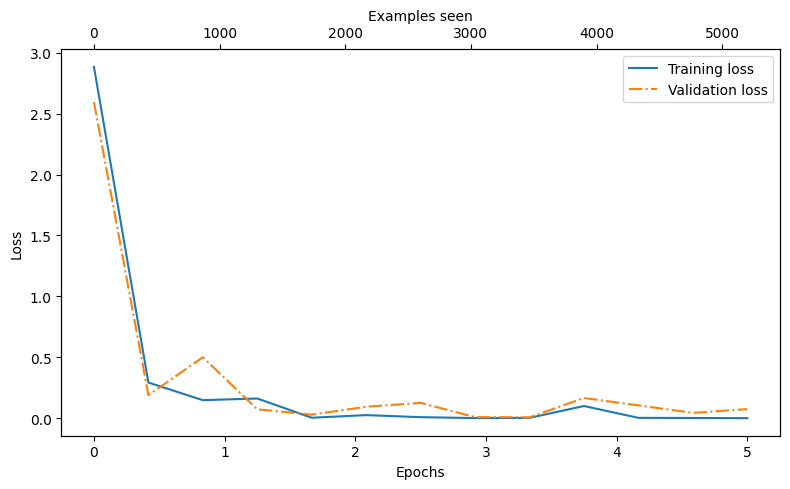

In [93]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

- The plot above shows the model's training and validation loss over the five training epochs. The training loss, represented by the solid line, and the validation loss, represented by the dashed line, both sharply decline in the first epoch and gradually stabilize towards the fifth epoch. This pattern indicates good learning progress and suggests that the model learned from the training data while generalizing well to the unseen validation data.

- Above, based on the downward slope, we see that the model learns well

- Furthermore, the fact that the training and validation loss are very close indicates that the model does not tend to overfit the training data

**CHOOSING THE NUMBER OF EPOCHS**

```
Earlier, when we initiated the training, we set the number of epochs to 5. The number of epochs depends on the dataset and the task's difficulty, and there is no universal solution or recommendation. An epoch number of 5 is usually a good starting point. If the model overfits after the first few epochs, we may need to reduce the number of epochs. Conversely, if the trendline suggests that the validation loss could improve with further training, we should increase the number of epochs. In this concrete case 5 epochs was a reasonable number as there is no sign of early overfitting, and the validation loss is close to 0.```

- Similarly, we can plot the accuracy below

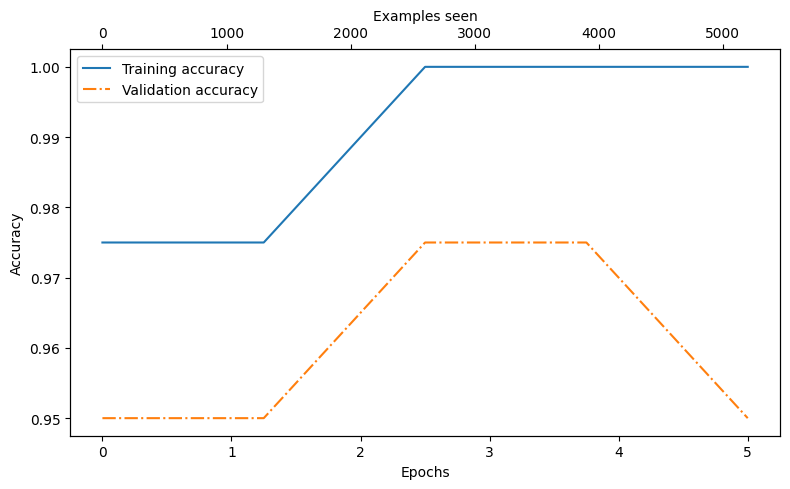

In [94]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

- Based on the accuracy plot above, we can see that the model achieves a relatively high training and validation accuracy after epochs 4 and 5.

- However, we have to keep in mind that we specified `eval_iter=5` in the training function earlier, which means that we only estimated the training and validation set performances.

- We can compute the training, validation, and test set performances over the complete dataset as follows below;

In [95]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 99.90%
Validation accuracy: 97.32%
Test accuracy: 97.00%


<!-- - The training and test set performances are almost identical. -->

- However, based on the slightly lower test set performance, we can see that the model overfits the training data to a very small degree, as well as the validation data that has been used for tweaking some of the hyperparameters, such as the learning rate

- This is normal, however, and this gap could potentially be further reduced by increasing the model's dropout rate `(drop_rate)` or the `weight_decay` in the optimizer setting

### **8. Using the LLM as a spam classifier**

After finetuning and evaluating the model in the previous sections, we are now in the final stage of this section, using the model to classify spam messages.


![Alt text](../../assests/figure618.png)


- Finally, let's use the finetuned GPT model in action

- The `classify_review` function below implements the data preprocessing steps similar to the `SpamDataset` we implemented earlier

- Then, the function returns the predicted integer class label from the model and returns the corresponding class name

In [96]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    # Note: In the book, this was originally written as pos_emb.weight.shape[1] by mistake
    # It didn't break the code but would have caused unnecessary truncation (to 768 instead of 1024)

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]
    assert max_length is not None, (
        "max_length must be specified. If you want to use the full model context, "
        "pass max_length=model.pos_emb.weight.shape[0]."
    )
    assert max_length <= supported_context_length, (
        f"max_length ({max_length}) exceeds model's supported context length ({supported_context_length})."
    )    
    # Alternatively, a more robust version is the following one, which handles the max_length=None case better
    # max_len = min(max_length,supported_context_length) if max_length else supported_context_length
    # input_ids = input_ids[:max_len]
    
    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

- Let's try it out on a few examples below

In [97]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [98]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [102]:
text_3 = (
    "Pain and suffering is absolutely necessary to forge strong character and resilience"
    "Buy my Book which gives more insights on how to navigate life."
)

print(classify_review(
    text_3, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


- The model makes correct predictions and returns an appropriate label.

- Finally, let's save the model in case we want to reuse the model later without having to train it again.

In [103]:
torch.save(model.state_dict(), "review_classifier.pth")

- Then, in a new session, we could load the model as follows

In [104]:
model_state_dict = torch.load("review_classifier.pth", map_location=device, weights_only=True)
model.load_state_dict(model_state_dict)

<All keys matched successfully>